任务1: 5×5随机收益率矩阵与等权组合收益计算

【5×5收益率矩阵】(5天 × 5只股票):
[[ 0.01093428 -0.00176529  0.01395377  0.0314606  -0.00368307]
 [-0.00368274  0.03258426  0.01634869 -0.00838949  0.0118512 ]
 [-0.00826835 -0.0083146   0.00583925 -0.0372656  -0.03349836]
 [-0.01024575 -0.01925662  0.00728495 -0.01716048 -0.02724607]
 [ 0.03031298 -0.00351553  0.00235056 -0.02749496 -0.00988765]]

【等权权重向量】: [0.2 0.2 0.2 0.2 0.2]

【等权组合每日收益率】:
[ 0.01018006  0.00974238 -0.01630153 -0.0133248  -0.00164692]
  第1天: 1.0180%
  第2天: 0.9742%
  第3天: -1.6302%
  第4天: -1.3325%
  第5天: -0.1647%

组合平均日收益: -0.2270%
组合收益方差: 0.012376%
组合收益标准差: 1.1125%

任务2: 手动特征分解 vs PCA对比

下载股票数据: ['AAPL', 'MSFT', 'GOOGL']
第1次下载成功
收益率全部数据: Ticker            AAPL       GOOGL        MSFT
Date                                          
2023-11-01  171.796463  125.413460  339.520355
2023-11-02  175.351486  126.444931  341.727753
2023-11-03  174.442978  128.041748  346.122955
2023-11-06  176.990738  129.182312  349.782349
2023-11-07  179.548401  129.896408  35

findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei



收益率数据形状: (249, 10)
时间范围: 2023-01-04 至 2023-12-29

【各主成分解释的方差比例】:
  第1主成分 (PC1): 40.56%
  第2主成分 (PC2): 16.62%
  第3主成分 (PC3): 9.43%
  第4主成分 (PC4): 7.87%
  第5主成分 (PC5): 6.21%
  第6主成分 (PC6): 5.79%
  第7主成分 (PC7): 4.61%
  第8主成分 (PC8): 3.46%
  第9主成分 (PC9): 3.01%
  第10主成分 (PC10): 2.45%

【关键结果】
第一主成分解释的总方差比例: 40.56%

【累计方差解释比例】:
  前1个主成分: 40.56%
  前2个主成分: 57.18%
  前3个主成分: 66.61%
  前4个主成分: 74.48%
  前5个主成分: 80.68%
  前6个主成分: 86.47%
  前7个主成分: 91.08%
  前8个主成分: 94.54%
  前9个主成分: 97.55%
  前10个主成分: 100.00%


/tmp/ipykernel_2365/2526510725.py:222: UserWarning: Glyph 20027 (\N{CJK UNIFIED IDEOGRAPH-4E3B}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2365/2526510725.py:222: UserWarning: Glyph 25104 (\N{CJK UNIFIED IDEOGRAPH-6210}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_2365/2526510725.py:222: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Gene


✓ 图表已保存至: /mnt/d/develop/quant/quant-trade-tutorial/test/pca_analysis.png

【分析解读】
第一主成分解释了 40.56% 的总方差。
→ 这表明股票之间存在中等程度的相关性。
→ 除了市场因子外，行业因子和个股特异性因素也起作用。

→ 前3个主成分累计解释了 66.61% 的方差，
  说明我们可以用3个因子来近似描述这10只股票的主要波动。

所有任务完成！


findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not found because none of the following families were found: SimHei
findfont: Generic family 'sans-serif' not foun

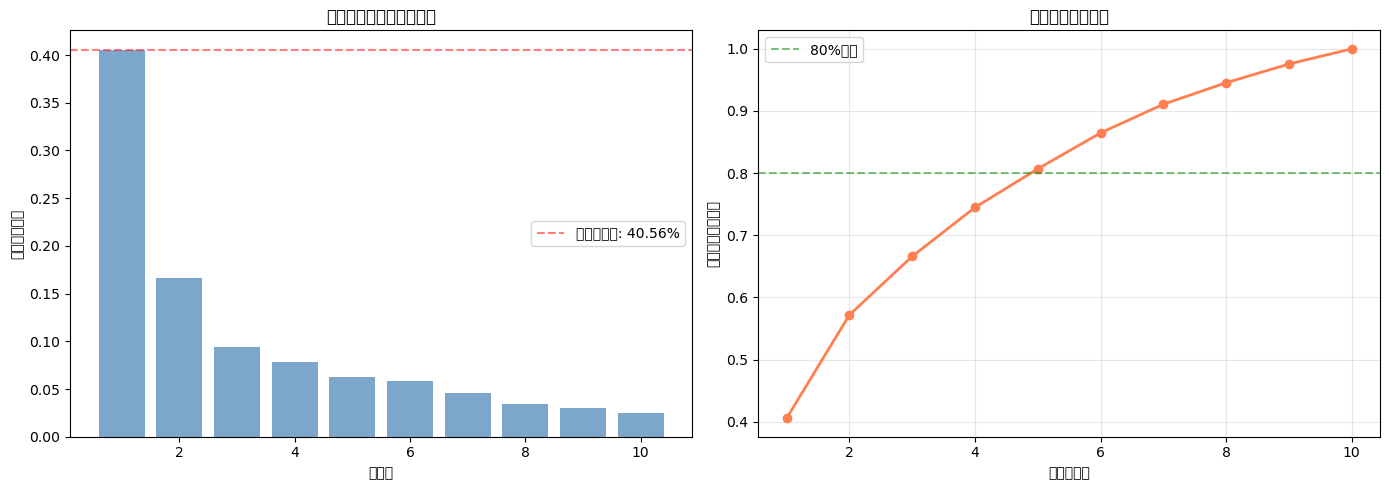

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import yfinance as yf
import time

# ==========================================
# 任务1: 创建5×5随机收益率矩阵，计算等权组合收益
# ==========================================
print("=" * 60)
print("任务1: 5×5随机收益率矩阵与等权组合收益计算")
print("=" * 60)

# 设置随机种子以确保结果可复现
np.random.seed(42)

# 创建5×5的随机收益率矩阵
# 假设我们有5只股票，5个交易日的收益率数据
# 使用正态分布模拟：均值0.001(日收益0.1%)，标准差0.02(日波动2%)
return_matrix = np.random.normal(loc=0.001, scale=0.02, size=(5, 5))

print("\n【5×5收益率矩阵】(5天 × 5只股票):")
print(return_matrix)

# 创建等权权重向量：5只股票，每只权重20%
weights = np.array([0.2, 0.2, 0.2, 0.2, 0.2])
print(f"\n【等权权重向量】: {weights}")

# 使用矩阵乘法计算每天组合的收益率
# 公式: R_portfolio = R_matrix × w
# return_matrix形状(5,5) × weights形状(5,) = 组合收益形状
# 把每个乘积加起来得总和就是：等权组合收益
portfolio_returns = np.dot(return_matrix, weights)

print("\n【等权组合每日收益率】:")
print(portfolio_returns)
for i, ret in enumerate(portfolio_returns):
    print(f"  第{i+1}天: {ret:.4%}")

print(f"\n组合平均日收益: {portfolio_returns.mean():.4%}")
print(f"组合收益方差: {portfolio_returns.var():.6%}")
print(f"组合收益标准差: {portfolio_returns.std():.4%}")


# ==========================================
# 任务2: 手动计算特征值/特征向量，与PCA对比
# ==========================================
print("\n" + "=" * 60)
print("任务2: 手动特征分解 vs PCA对比")
print("=" * 60)

# 下载3只股票的真实数据用于计算协方差矩阵
tickers_3 = ['AAPL', 'MSFT', 'GOOGL']
print(f"\n下载股票数据: {tickers_3}")

for i in range(3):
    data_3 = yf.download(tickers_3, start='2023-11-01', end='2024-01-01', progress=False)['Close']
    if not data_3.empty:
        print(f"第{i+1}次下载成功")
        break
    else:
        print(f"第{i+1}次下载失败，等待5秒重试...")
        time.sleep(5)

if data_3.empty:
    print("数据下载失败，使用模拟数据")
    # 如果下载失败，使用模拟数据
    np.random.seed(42)
    data_3 = pd.DataFrame(# 该函数可以加列名和自增主键列
        np.random.normal(150, 20, (25, 3)),
        columns=tickers_3
    )
    print(f"数据为：\n {data_3}")

# 计算收益率
rets_3 = data_3.pct_change().dropna()
print(f"原始数据: {data_3}")
print(f"收益率全部数据: {rets_3}")
print(f"收益率数据形状: {rets_3.shape}")

# 计算3×3协方差矩阵
cov_matrix = rets_3.cov()
print("\n【3×3协方差矩阵】:")
print(cov_matrix)

# --- 方法1: 使用np.linalg.eig()手动计算特征值和特征向量 ---
eigenvalues, eigenvectors = np.linalg.eig(cov_matrix)
#  把协方差矩阵拆开，找出这三个股票最主要的“共同波动方向”。
##  np.linalg.eig 函数，把一个复杂的矩阵，分解成“方向”和“力度”两部分。
## 特征向量：代表方向（在这个方向上，数据变化最剧烈）
## 特征值：代表力度（在这个方向上的变化有多大）
print("\n【手动计算 - 特征值】:")
print(eigenvalues)

print("\n【手动计算 - 特征向量】(每列是一个特征向量):")
print(eigenvectors)

# 按特征值大小排序（从大到小）
sorted_idx = np.argsort(eigenvalues)[::-1] #argsort把特征值从小到大排序，[::-1]反转数组，把“从小到大”变成“从大到小”，拿到“从大到小”的索引
eigenvalues_sorted = eigenvalues[sorted_idx]#把特征值按索引重新排
eigenvectors_sorted = eigenvectors[:, sorted_idx]#把特征向量也按同样的索引重排

print("\n【排序后的特征值】:")
print(eigenvalues_sorted)
print("\n【排序后的特征向量】:")
print(eigenvectors_sorted)

# 计算每个特征值解释的方差比例
total_variance = eigenvalues_sorted.sum() #特征值求和
explained_variance_ratio_manual = eigenvalues_sorted / total_variance
print("\n【手动计算 - 各方差解释比例】:")
for i, ratio in enumerate(explained_variance_ratio_manual):
    print(f"  第{i+1}主成分: {ratio:.2%}")
# enumerate() 干了什么
#它把每个元素拆成 (索引, 值) 一对：
# enumerate([0.5604, 0.3513, 0.0883])
# → (0, 0.5604), (1, 0.3513), (2, 0.0883)

# --- 方法2: 使用sklearn的PCA ---
pca_3 = PCA(n_components=3) # 告诉算法：三维数据计算
pca_3.fit(rets_3) # rets_3是收益率数据

print("\n【PCA计算 - 特征值】:")
print(pca_3.explained_variance_)

print("\n【PCA计算 - 方差解释比例】:")
print(pca_3.explained_variance_ratio_)# 各个成分解释了多少总方差

# --- 对比结果 ---
print("\n【对比结果】:")
print(f"手动计算方差比例: {explained_variance_ratio_manual}")
print(f"PCA计算方差比例:  {pca_3.explained_variance_ratio_}")
print(f"差异: {np.abs(explained_variance_ratio_manual - pca_3.explained_variance_ratio_)}")
print("✓ 两种方法结果应该非常接近（微小差异来自数值计算精度）")


# ==========================================
# 任务3: 对10只标普500股票进行PCA分析
# ==========================================
print("\n" + "=" * 60)
print("任务3: 10只标普500股票的PCA分析")
print("=" * 60)

# 选择标普500中的10只代表性股票（覆盖不同行业）
tickers_10 = [
    'AAPL',   # 科技 - 苹果
    'MSFT',   # 科技 - 微软
    'GOOGL',  # 科技 - 谷歌
    'AMZN',   # 消费 - 亚马逊
    'JPM',    # 金融 - 摩根大通
    'JNJ',    # 医疗 - 强生
    'V',      # 金融 - Visa
    'PG',     # 消费 - 宝洁
    'XOM',    # 能源 - 埃克森美孚
    'UNH'     # 医疗 - 联合健康
]

print(f"\n下载10只标普500成分股数据: {tickers_10}")

for i in range(3):
    try:
        data_10 = yf.download(tickers_10, start='2023-01-01', end='2024-01-01', progress=False)['Close']
        if not data_10.empty:
            break
    except Exception as e:
        print(f"第{i+1}次下载失败: {e}")
        time.sleep(5)

if data_10.empty:
    print("数据下载失败，程序终止")
else:
    # 计算收益率
    rets_10 = data_10.pct_change().dropna()
    print(f"\n收益率数据形状: {rets_10.shape}")
    print(f"时间范围: {rets_10.index[0].date()} 至 {rets_10.index[-1].date()}")
    
    # 执行PCA分析
    pca_10 = PCA(n_components=10)# 创建一个空的 PCA 模型，还没开始计算。10 只股票，所以最多有 10 个主成分
    pca_10.fit(rets_10)#计算 10 只股票的协方差矩阵（10×10）#对协方差矩阵做特征值分解#按特征值从大到小排序
    
    # 输出每个主成分解释的方差比例
    print("\n【各主成分解释的方差比例】:")
    for i, ratio in enumerate(pca_10.explained_variance_ratio_):
        print(f"  第{i+1}主成分 (PC{i+1}): {ratio:.2%}")
    
    # 第一主成分解释的方差比例
    first_pc_ratio = pca_10.explained_variance_ratio_[0]
    print(f"\n【关键结果】")
    print(f"第一主成分解释的总方差比例: {first_pc_ratio:.2%}")
    
    # 前几个主成分累计解释的方差
    cumulative_variance = np.cumsum(pca_10.explained_variance_ratio_)
    print("\n【累计方差解释比例】:")
    for i, cum_ratio in enumerate(cumulative_variance):
        print(f"  前{i+1}个主成分: {cum_ratio:.2%}")
    
    # 获取 PCA 的组件（特征向量）
    pc1_loadings = pca_10.components_[0]  # 第一主成分的权，components就是特征向量10*10的矩阵
    # 找绝对值最大的
    dominant_idx = np.argmax(np.abs(pc1_loadings))# abs取绝对值，argmax找最大值的索引
    dominant_stock = data_10.columns[dominant_idx]# data_10.columns 是股票名列表
    dominant_weight = pc1_loadings[dominant_idx]# 取回原始权重值
    
    # 打印所有股票的 PC1 权重
    print("\n【PC1 各股票权重】:")
    for i, ticker in enumerate(data_10.columns):
        print(f"  {ticker}: {pc1_loadings[i]:.4f}")
    
    print(f"\nPC1 主导股票: {dominant_stock} (权重: {dominant_weight:.4f})")

    # 可视化
    plt.rcParams['font.sans-serif'] = ['SimHei', 'Microsoft YaHei', 'WenQuanYi Zen Hei']
    plt.rcParams['axes.unicode_minus'] = False#让 Matplotlib 在显示中文时，负号 - 能正常显示，不会变成方块或乱码。
    
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))# 创建一张画布，上面并排放两张子图
    #包含两个子图的数组	axes[0] 操作左图，axes[1] 操作右图
    #宽 14 英寸，高 5 英寸	整张画布的大小

    # 图1: 各主成分解释方差比例
    axes[0].bar(range(1, 11), pca_10.explained_variance_ratio_, color='steelblue', alpha=0.7)
    axes[0].set_xlabel('主成分')
    axes[0].set_ylabel('解释方差比例')
    axes[0].set_title('各主成分解释的方差比例')
    axes[0].axhline(y=first_pc_ratio, color='red', linestyle='--', alpha=0.5, 
                    label=f'第一主成分: {first_pc_ratio:.2%}')
    axes[0].legend()
    
    # 图2: 累计解释方差比例
    axes[1].plot(range(1, 11), cumulative_variance, marker='o', color='coral', linewidth=2)
    axes[1].axhline(y=0.80, color='green', linestyle='--', alpha=0.5, label='80%阈值')
    axes[1].set_xlabel('主成分数量')
    axes[1].set_ylabel('累计解释方差比例')
    axes[1].set_title('累计方差解释比例')
    axes[1].legend()
    axes[1].grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig('/mnt/d/develop/quant/quant-trade-tutorial/test/pca_analysis.png', dpi=150)
    print("\n✓ 图表已保存至: /mnt/d/develop/quant/quant-trade-tutorial/test/pca_analysis.png")
    
    # 分析第一主成分的含义
    print("\n【分析解读】")
    print(f"第一主成分解释了 {first_pc_ratio:.2%} 的总方差。")
    if first_pc_ratio > 0.5:
        print("→ 这表明10只股票之间存在很强的共同运动模式（市场因子）。")
        print("→ 第一主成分通常代表'市场整体走势'，即系统性风险。")
    elif first_pc_ratio > 0.3:
        print("→ 这表明股票之间存在中等程度的相关性。")
        print("→ 除了市场因子外，行业因子和个股特异性因素也起作用。")
    else:
        print("→ 这表明股票之间的相关性较弱。")
        print("→ 个股特异性因素主导了价格变动。")
    
    print(f"\n→ 前3个主成分累计解释了 {cumulative_variance[2]:.2%} 的方差，")
    print("  说明我们可以用3个因子来近似描述这10只股票的主要波动。")

print("\n" + "=" * 60)
print("所有任务完成！")
print("=" * 60)